In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import statsmodels.formula.api as smf
from tqdm import tqdm
from scipy import stats
from google.colab import drive
from statsmodels.iolib.summary2 import summary_col
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/sessions_14days.csv')

Mounted at /content/drive


Гипотеза 2: Влияние количества просмотров на вероятность совершения покупки

=== ОПИСАТЕЛЬНАЯ СТАТИСТИКА ===
Группа 'ПОКУПКА' (views):
count    284568.000000
mean          5.259994
std           7.098993
min           0.000000
25%           2.000000
50%           3.000000
75%           6.000000
max         308.000000
Name: views, dtype: float64
Скошенность: 5.892

Группа 'НЕТ ПОКУПКИ' (views):
count    3.871545e+06
mean     4.076778e+00
std      6.094887e+00
min      0.000000e+00
25%      1.000000e+00
50%      2.000000e+00
75%      4.000000e+00
max      1.135000e+03
Name: views, dtype: float64
Скошенность: 8.148


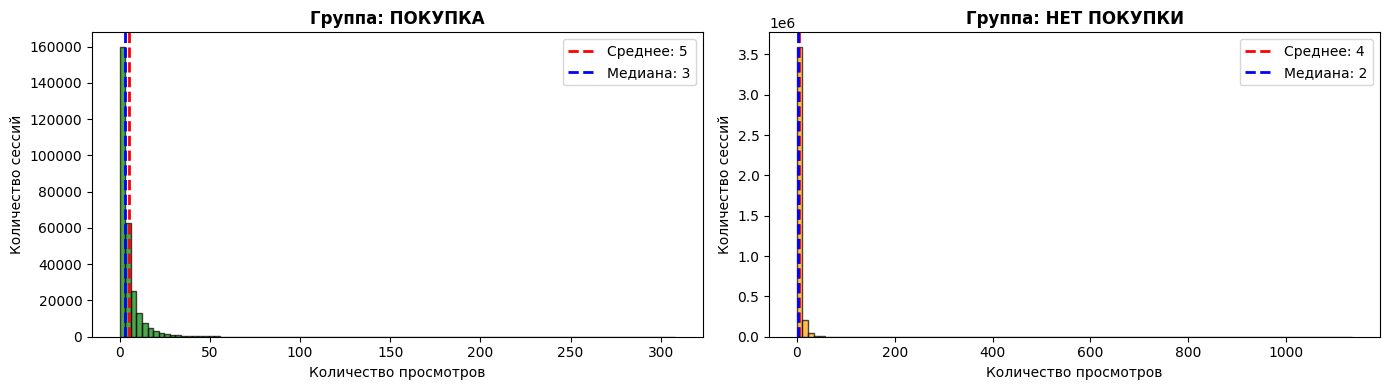

In [2]:
# Группировка данных
views_buy = df[df['made_purchase'] == 1]['views']
views_no_buy = df[df['made_purchase'] == 0]['views']

print("=== ОПИСАТЕЛЬНАЯ СТАТИСТИКА ===")
print("Группа 'ПОКУПКА' (views):")
print(views_buy.describe())
print(f"Скошенность: {views_buy.skew():.3f}\n")

print("Группа 'НЕТ ПОКУПКИ' (views):")
print(views_no_buy.describe())
print(f"Скошенность: {views_no_buy.skew():.3f}")


fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Гистограмма — покупка
axes[0].hist(views_buy, bins=100, alpha=0.7, edgecolor='black', color='green')
axes[0].axvline(views_buy.mean(), color='red', linestyle='--', linewidth=2, label=f'Среднее: {views_buy.mean():.0f}')
axes[0].axvline(views_buy.median(), color='blue', linestyle='--', linewidth=2, label=f'Медиана: {views_buy.median():.0f}')
axes[0].set_title('Группа: ПОКУПКА', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Количество просмотров')
axes[0].set_ylabel('Количество сессий')
axes[0].legend()

# Гистограмма — нет покупки
axes[1].hist(views_no_buy, bins=100, alpha=0.7, edgecolor='black', color='orange')
axes[1].axvline(views_no_buy.mean(), color='red', linestyle='--', linewidth=2, label=f'Среднее: {views_no_buy.mean():.0f}')
axes[1].axvline(views_no_buy.median(), color='blue', linestyle='--', linewidth=2, label=f'Медиана: {views_no_buy.median():.0f}')
axes[1].set_title('Группа: НЕТ ПОКУПКИ', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Количество просмотров')
axes[1].set_ylabel('Количество сессий')
axes[1].legend()

plt.tight_layout()
plt.show()

Данные сильно скошены (skewness > 5), что искажает непрерывные тесты (бутстреп, t-тест).  

Биннинг + логистическая регрессия - стабилизирует оценки и дают бизнес-метрики


In [5]:
df[(df['views'] == 0) & (df['purchases'] == 0)].head(1) # ноль просмотров, но товар был добавлен в корзину, либо была совершена покупка.

,user_session,user_id,weekday,is_weekend,start_hour,events_count,views,carts,purchases,made_purchase,added_to_cart,avg_price,max_price,main_category_viewed
8867,3ad49e19-5020-4a9d-83d4-de8ab468c32b,543665042,4,0,10,1,0,1,0,0,1,250.64,250.64,NaN


КОНВЕРСИЯ ПО КАТЕГОРИЯМ ПРОСМОТРОВ
            views_cat  num_sessions  num_purchases  conversion
0  0 (прямая покупка)           943            506       53.66
1                   1       1592717          48813        3.06
3                 2-3       1202391         110530        9.19
4                 4-5        504885          47889        9.49
5                6-10        501213          45007        8.98
2                 11+        353964          31823        8.99

LOGIT REGRESSION RESULTS (полная таблица)
                           Logit Regression Results                           
Dep. Variable:          made_purchase   No. Observations:              4156113
Model:                          Logit   Df Residuals:                  4156107
Method:                           MLE   Df Model:                            5
Date:                Wed, 01 Apr 2026   Pseudo R-squ.:                 0.03175
Time:                        10:23:34   Log-Likelihood:            -1.0047e+06
converg

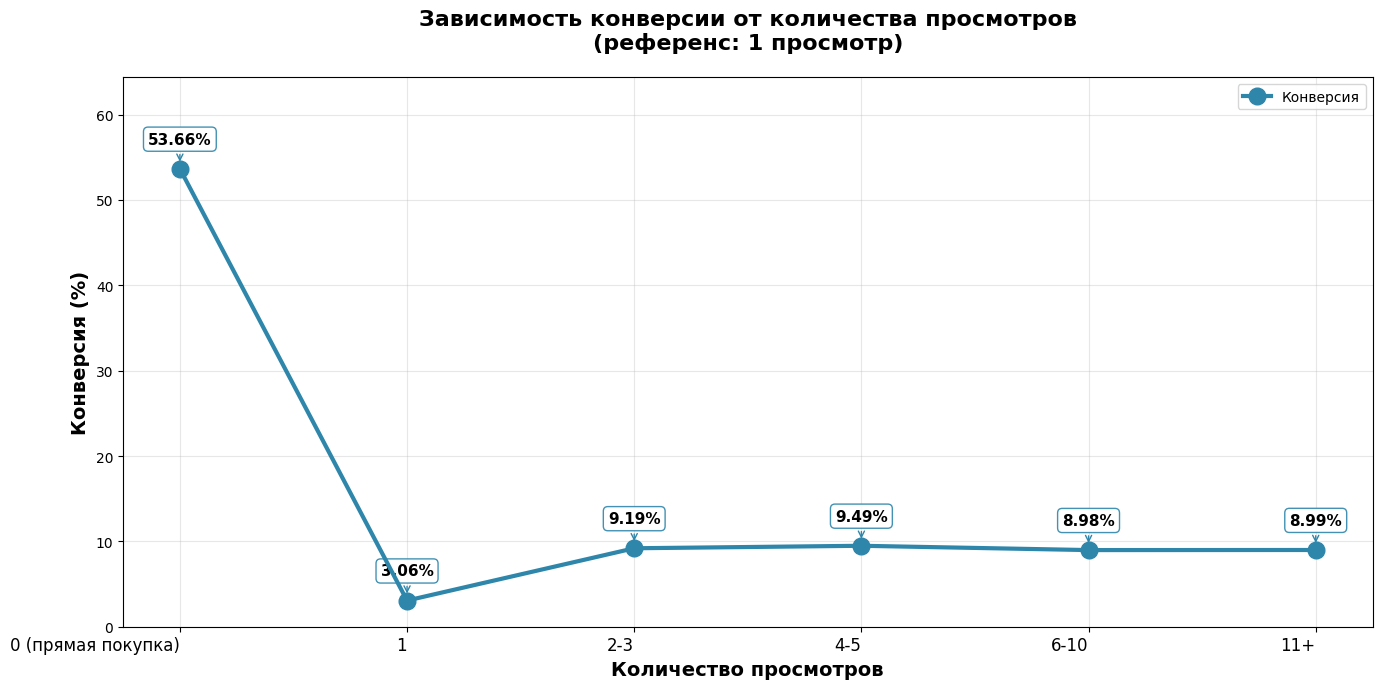

In [13]:
# Категоризация
def views_category(views):
    if views == 0:
        return '0 (прямая покупка)'
    elif views == 1:
        return '1'
    elif views <= 3:
        return '2-3'
    elif views <= 5:
        return '4-5'
    elif views <= 10:
        return '6-10'
    else:
        return '11+'

df['views_cat'] = df['views'].apply(views_category)

# Конверсия
cat_order = ['0 (прямая покупка)', '1', '2-3', '4-5', '6-10', '11+']
conv = df.groupby('views_cat', observed=False).agg(
    num_sessions=('made_purchase', 'count'),
    num_purchases=('made_purchase', 'sum'),
    conversion=('made_purchase', 'mean')
).reset_index()

conv['views_cat'] = pd.Categorical(conv['views_cat'], categories=cat_order, ordered=True)
conv = conv.sort_values('views_cat')
conv['conversion'] = conv['conversion'] * 100
conv['num_purchases'] = conv['num_purchases'].astype(int)

print("КОНВЕРСИЯ ПО КАТЕГОРИЯМ ПРОСМОТРОВ")
print(conv.round(2))

# Логистическая регрессия
model = smf.logit('made_purchase ~ C(views_cat, Treatment(reference="1"))', data=df).fit(disp=0)

# LOGIT REGRESSION RESULTS
print("\n" + "="*80)
print("LOGIT REGRESSION RESULTS (полная таблица)")
print("="*80)
print(model.summary())

# ODDS RATIOS
params = model.params
conf = model.conf_int()
pvals = model.pvalues

or_table = pd.DataFrame({
    'Категория': [cat.replace('C(views_cat, Treatment(reference="1"))[T.', '').replace(']', '')
                  for cat in params.index[1:]],
    'OR_относительно_1': np.exp(params)[1:].round(3),
    'CI_нижн': np.exp(conf[0])[1:].round(3),
    'CI_верхн': np.exp(conf[1])[1:].round(3),
    'p_value': pvals[1:].round(3)
})

print("\n=== ODDS RATIOS (относительно 1 просмотра) ===")
print(or_table.to_string(index=False))


# График
plt.figure(figsize=(14, 7))
x_pos = np.arange(len(conv))

plt.plot(x_pos, conv['conversion'], marker='o', linewidth=3, markersize=12,
         color='#2E86AB', label='Конверсия', zorder=5)


for i, (x, y) in enumerate(zip(x_pos, conv['conversion'])):
    plt.annotate(f'{y:.2f}%', (x, y+0.5), xytext=(0, 15),
                textcoords="offset points", ha='center', fontsize=11, fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.9, ec='#2E86AB'),
                arrowprops=dict(arrowstyle='->', color='#2E86AB', lw=1))

plt.xticks(x_pos, conv['views_cat'], ha='right', fontsize=12)
plt.xlabel('Количество просмотров', fontsize=14, fontweight='bold')
plt.ylabel('Конверсия (%)', fontsize=14, fontweight='bold')
plt.title('Зависимость конверсии от количества просмотров\n(референс: 1 просмотр)',
          fontsize=16, fontweight='bold', pad=20)
plt.ylim(0, max(conv['conversion'])*1.2)
plt.legend(loc='upper right')

plt.tight_layout()
plt.savefig('hypothesis_2_views_perfect.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()



Гипотеза подтверждена.

Прямая покупка — +36% vs 1 просмотр. Хотелось бы изучить детальнее.

1 просмотр = критическая точка (самая низкая конверсия)

Множество просмотров НЕ улучшает конверсию (3.1x vs 36x)